# "the human" -> "the person" / "the user"

`data/system-prompts_en.md` 内の各システムプロンプト版（日付 x モデル）で、人物を指す語がどう推移したかを集計・可視化する。

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

SRC = Path("data/system-prompts_en.md")

## 抽出

`## モデル名` と `<Accordion title="日付">` の見出しでエントリに分割し、各エントリ本文中の "the human" / "the person" / "the user" の出現回数を数える。

In [2]:
lines = SRC.read_text().split("\n")

entries = []
current_model = None
for i, line in enumerate(lines):
    m = re.match(r"^## (.+)", line)
    if m:
        current_model = m.group(1).strip()
        continue
    m = re.match(r'\s*<Accordion title="(.+)">', line)
    if m:
        entries.append({"model": current_model, "date": m.group(1).strip(), "start": i})

for idx, e in enumerate(entries):
    e["end"] = entries[idx + 1]["start"] if idx + 1 < len(entries) else len(lines)

rows = []
for e in entries:
    text = "\n".join(lines[e["start"]:e["end"]]).lower()
    rows.append({
        "date": pd.to_datetime(e["date"]),
        "model": e["model"],
        "the human": len(re.findall(r"\bthe human\b", text)),
        "the person": len(re.findall(r"\bthe person\b", text)),
        "the user": len(re.findall(r"\bthe user\b", text)),
    })

df = pd.DataFrame(rows).sort_values(["date", "model"]).reset_index(drop=True)
df

,date,model,the human,the person,the user
0,2024-07-12,Claude Haiku 3,1,0,0
1,2024-07-12,Claude Opus 3,3,1,1
2,2024-07-12,Claude Sonnet 3.5,6,3,14
3,2024-09-09,Claude Sonnet 3.5,13,3,26
4,2024-10-22,Claude Haiku 3.5,35,33,6
5,2024-10-22,Claude Sonnet 3.5,83,3,2
6,2024-11-22,Claude Sonnet 3.5,79,3,2
7,2025-02-24,Claude Sonnet 3.7,7,35,0
8,2025-05-22,Claude Opus 4,4,24,9
9,2025-05-22,Claude Sonnet 4,4,24,9


## プロット

- 横軸: 日付（システムプロンプトが更新された日）
- 縦軸: 語の出現回数
- 折れ線の色: the human / the person / the user
- 点: システムプロンプトの1バージョン（同日付・同カウントで複数モデルが並ぶ場合はモデル名をまとめて1点にする）
- 各点の斜め上にモデル名を表示

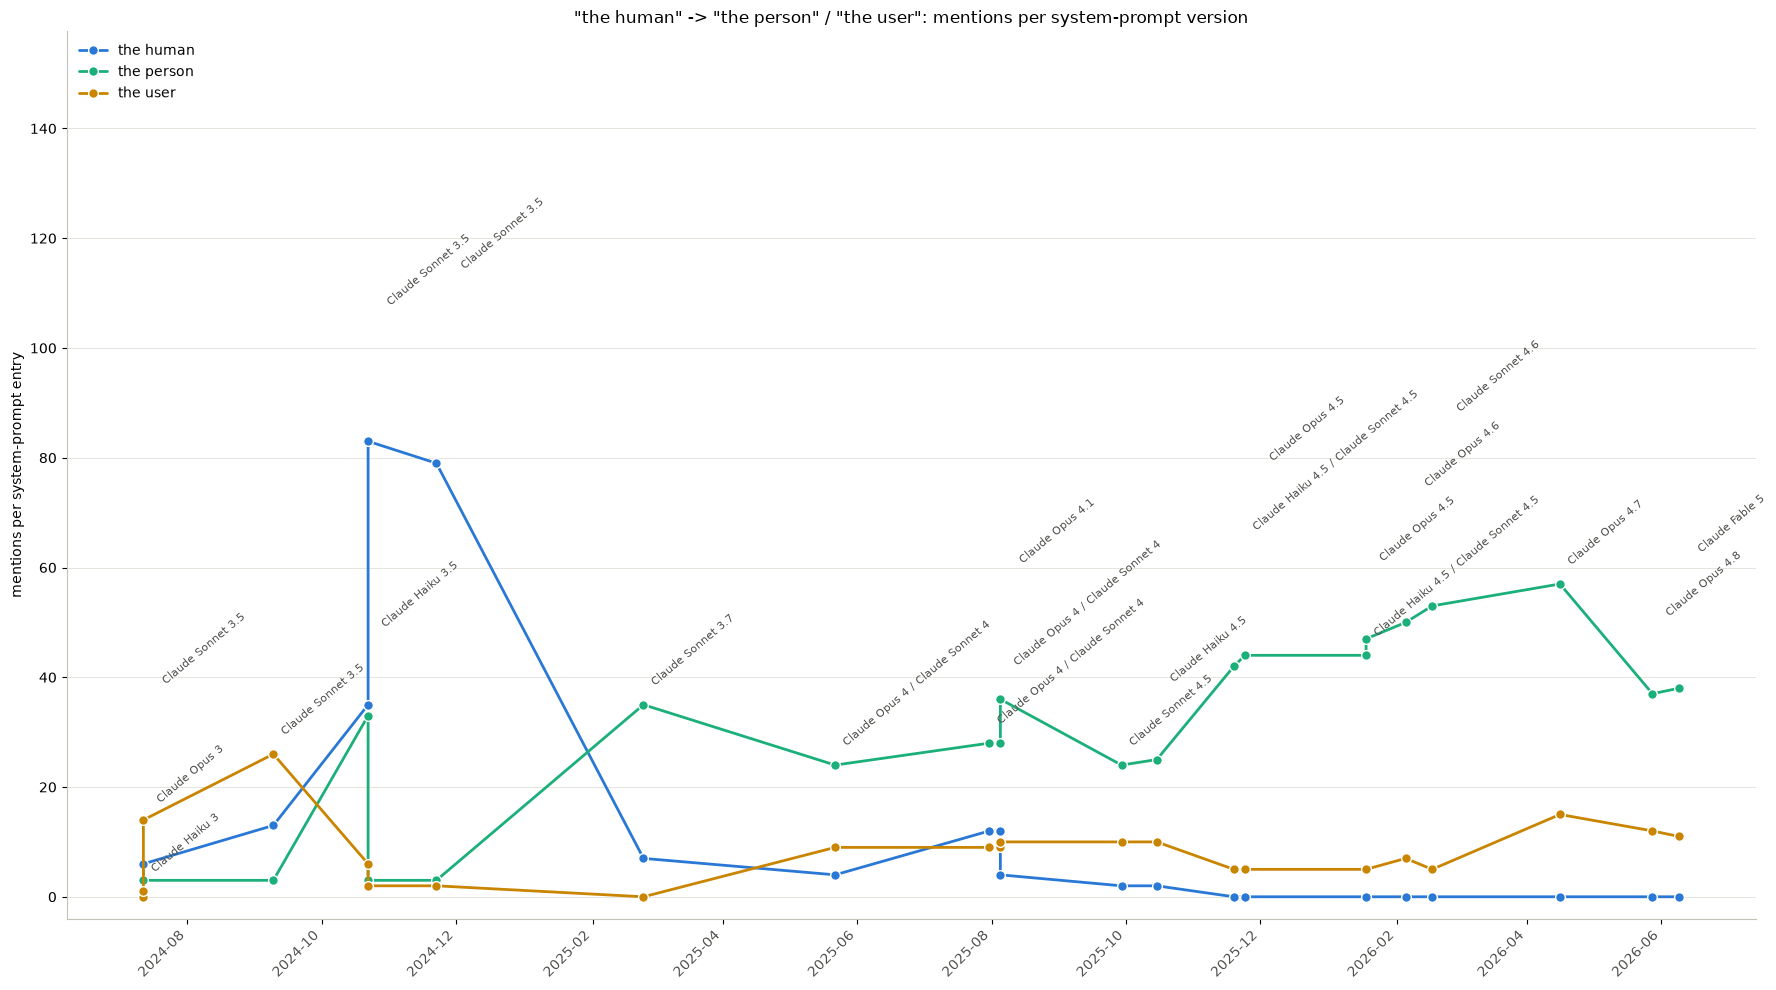

In [ ]:
SERIES = [
    ("the human", "#2a78d6"),
    ("the person", "#1baf7a"),
    ("the user", "#c98500"),
]

# 同日付・同カウントのエントリ（複数モデルで同一プロンプト）は1点にまとめ、モデル名を連結する
grouped = (
    df.groupby(["date", "the human", "the person", "the user"])["model"]
    .apply(lambda s: " / ".join(sorted(s)))
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

# 日付が近い点(45日以内)は同じクラスタとみなし、クラスタ内で段違いにラベルを積む
dates_num = mdates.date2num(grouped["date"])
CLUSTER_GAP_DAYS = 45
cluster = [0]
for i in range(1, len(dates_num)):
    gap = dates_num[i] - dates_num[i - 1]
    cluster.append(cluster[-1] + 1 if gap > CLUSTER_GAP_DAYS else cluster[-1])
grouped["cluster"] = cluster
grouped["stagger"] = grouped.groupby("cluster").cumcount()

fig, ax = plt.subplots(figsize=(18, 10))

for col, color in SERIES:
    ax.plot(
        grouped["date"], grouped[col],
        color=color, linewidth=2, marker="o", markersize=7,
        markeredgecolor="white", markeredgewidth=1,
        solid_capstyle="round", label=col, zorder=3,
    )

y_max = df[["the human", "the person", "the user"]].values.max()
ax.set_ylim(-4, y_max * 1.9)
ax.set_ylabel("mentions per system-prompt entry")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.6, zorder=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", color="#52514e")
ax.legend(frameon=False, loc="upper left")
ax.set_title(
    '"the human" -> "the person" / "the user": mentions per system-prompt version',
    fontsize=12,
)

# 各点の斜め上にモデル名。近接クラスタ内は段違いにスタックして衝突を避ける
for _, row in grouped.iterrows():
    top_y = max(row["the human"], row["the person"], row["the user"])
    ax.annotate(
        row["model"],
        xy=(row["date"], top_y),
        xytext=(4 + row["stagger"] * 4, 12 + row["stagger"] * 42),
        textcoords="offset points",
        rotation=40, ha="left", va="bottom",
        fontsize=8, color="#52514e",
    )

fig.tight_layout()
#fig.savefig("pronoun_shift.png", dpi=160, facecolor="white")
plt.show()